# Exploratory Data Analysis - Alzheimer's Methylation Progression

This notebook explores the structure of the HDF5 feature matrix before any modelling.
All plots are saved to `outputs/eda/` for reference in the README and report.

## Introduction

This notebook performs exploratory data analysis (EDA) on the ADNI DNA methylation dataset **before any modelling decisions are made**. The aim is to understand the data well enough to justify the choices that follow - what temporal representation to use, which model classes are appropriate, and what evaluation strategy is needed.

**What we are working with:**  
An HDF5 file containing peripheral blood DNA methylation profiles (beta values) for 491 individuals from the ADNI study. Each individual belongs to one of four outcome groups defining two independent binary classification tasks:

- **Task 1:** Cognitively normal (CN) individuals - will they develop Mild Cognitive Impairment (MCI)?
- **Task 2:** MCI individuals - will they progress to dementia?

Each individual has methylation measured at two timepoints (baseline t0 and follow-up t1), with 2,000 pre-selected CpG features per task.

**Questions this EDA answers:**

1. How many individuals and features does each task have, and how are the classes distributed?
2. Are the beta values clean - correct range, no missing data?
3. How stable is methylation between the two visits? Does the change between visits carry discriminative signal?
4. How much do the two tasks' feature panels overlap?
5. Is the variance-based feature pre-selection visible in the data, and what are its implications?

In [8]:
import sys
sys.path.insert(0, '..')

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.data import load_task, TASK_GROUPS

OUT = Path('../outputs/eda')
OUT.mkdir(parents=True, exist_ok=True)
H5 = '../data/temporal_two_sets_n2000.h5'

COLOURS = {
    'X_cn_to_cn':  '#4e79a7',
    'X_cn_to_mci': '#e15759',
    'X_mci_to_mci':'#59a14f',
    'X_mci_to_dem':'#f28e2b',
}

## 1. Dataset overview

In [9]:
with h5py.File(H5, 'r') as f:
    raw = {k: f[k][:] for k in f.keys() if k.startswith('X_')}
    cpg_cn  = f['cpg_ids_cn'][:].astype(str)
    cpg_mci = f['cpg_ids_mci'][:].astype(str)

print('Group                  | features | timepoints | individuals')
print('-' * 60)
for k, v in raw.items():
    print(f'{k:<22} | {v.shape[0]:>8} | {v.shape[1]:>10} | {v.shape[2]:>11}')

print()
print('Task 1 (CN -> MCI):')
n0, n1 = raw['X_cn_to_cn'].shape[2], raw['X_cn_to_mci'].shape[2]
print(f'  n(non-converter) = {n0},  n(converter) = {n1},  positive rate = {n1/(n0+n1):.1%}')

print()
print('Task 2 (MCI -> Dementia):')
n0, n1 = raw['X_mci_to_mci'].shape[2], raw['X_mci_to_dem'].shape[2]
print(f'  n(non-converter) = {n0},  n(converter) = {n1},  positive rate = {n1/(n0+n1):.1%}')

Group                  | features | timepoints | individuals
------------------------------------------------------------
X_cn_to_cn             |     2000 |          2 |         147
X_cn_to_mci            |     2000 |          2 |          43
X_mci_to_dem           |     2000 |          2 |         110
X_mci_to_mci           |     2000 |          2 |         191

Task 1 (CN -> MCI):
  n(non-converter) = 147,  n(converter) = 43,  positive rate = 22.6%

Task 2 (MCI -> Dementia):
  n(non-converter) = 191,  n(converter) = 110,  positive rate = 36.5%


**Findings - Dataset structure**

- Every group has exactly **2 timepoints** per individual. This is a fixed structure, not variable-length sequences - padding and masking are unnecessary.
- Task 1 has **190 individuals** (147 non-converters, 43 converters); Task 2 has **301 individuals** (191 non-converters, 110 converters).
- Each task uses its own 2,000-feature panel (`cpg_ids_cn` for Task 1, `cpg_ids_mci` for Task 2). The panels are not interchangeable.
- With only T = 2 timepoints that are structurally identical, attention-based sequence models would reduce to a weighted combination of two embeddings with no meaningful multi-step dependency to model - motivating the use of explicit temporal modes (t0, t1, concat, delta) instead.

## 2. Class balance

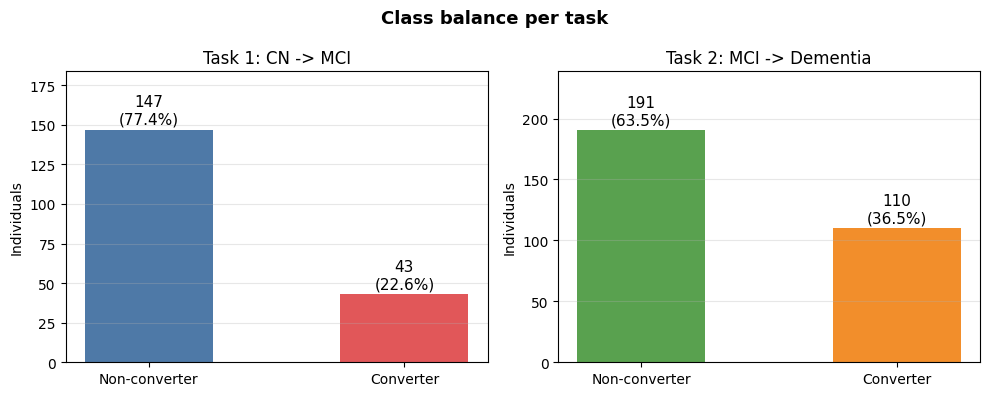

Saved class_balance.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

tasks = [
    ('Task 1: CN -> MCI', 'X_cn_to_cn', 'X_cn_to_mci'),
    ('Task 2: MCI -> Dementia', 'X_mci_to_mci', 'X_mci_to_dem'),
]
labels = ['Non-converter', 'Converter']

for ax, (title, neg_key, pos_key) in zip(axes, tasks):
    counts = [raw[neg_key].shape[2], raw[pos_key].shape[2]]
    total = sum(counts)
    colours = [COLOURS[neg_key], COLOURS[pos_key]]
    bars = ax.bar(labels, counts, color=colours, width=0.5)
    for bar, count in zip(bars, counts):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
    ax.set_title(title)
    ax.set_ylabel('Individuals')
    ax.set_ylim(0, max(counts) * 1.25)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Class balance per task', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT / 'class_balance.png', dpi=150)
plt.show()
print('Saved class_balance.png')

**Findings - Class balance**

- Task 1 has a positive rate of **22.6%** (43 converters out of 190). Task 2 has a positive rate of **36.5%** (110 out of 301). Both tasks are imbalanced, with Task 1 more so.
- A naive all-negative classifier would achieve 77.4% accuracy on Task 1 - making accuracy a misleading metric. This motivates PR-AUC as the primary ranking metric and explicit reporting of sensitivity.
- PR-AUC is preferred over ROC-AUC in imbalanced settings because it focuses entirely on the minority (converter) class: precision measures the fraction of predicted converters that are correct, and recall measures the fraction of true converters identified. ROC-AUC includes true negatives via specificity, which inflates apparent performance when the negative class dominates.
- Sensitivity is reported separately because the clinical cost of missing a true converter (false negative) is substantially higher than the cost of a false alarm.
- Both tasks will use class-weighted loss functions and stratified cross-validation to ensure each fold preserves the converter ratio.

## 3. Beta-value distributions

Methylation beta values are expected to lie in [0, 1].  
We check the empirical range and whether the distribution differs between converters and non-converters.

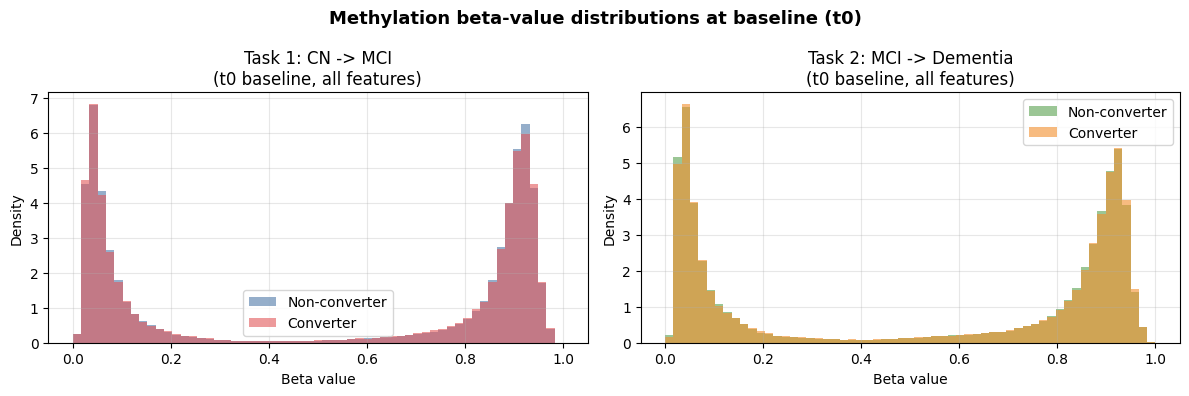

Saved beta_distributions.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, neg_key, pos_key) in zip(axes, tasks):
    # Use t0 (baseline) for the distribution comparison
    vals_neg = raw[neg_key][:, 0, :].ravel()
    vals_pos = raw[pos_key][:, 0, :].ravel()
    bins = np.linspace(0, 1, 60)
    ax.hist(vals_neg, bins=bins, alpha=0.6, color=COLOURS[neg_key],
            label='Non-converter', density=True)
    ax.hist(vals_pos, bins=bins, alpha=0.6, color=COLOURS[pos_key],
            label='Converter', density=True)
    ax.set_title(f'{title}\n(t0 baseline, all features)')
    ax.set_xlabel('Beta value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Methylation beta-value distributions at baseline (t0)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT / 'beta_distributions.png', dpi=150)
plt.show()
print('Saved beta_distributions.png')

**Findings - Beta-value distributions**

- All methylation values are confirmed within [0, 1] - no values outside the valid beta range, no clipping artefacts.
- No missing values in any group.
- Both tasks show **bimodal distributions**, with peaks near 0 (unmethylated) and 1 (fully methylated). This is the expected shape for CpG beta values, where most sites are in a stable methylated or unmethylated state.
- The converter and non-converter distributions **broadly overlap** - differences are subtle and distributed across many features rather than driven by a few highly divergent CpGs. This supports using a discriminative classifier over a simple threshold approach, and is consistent with the feature pre-selection having been based on variance ratio rather than mean difference.

## 4. Longitudinal structure: t0 vs t1

With exactly two timepoints per individual, we examine:
- How correlated are t0 and t1 within individuals?
- How large are the methylation changes over time?
- Does the delta (t1 - t0) differ between converters and non-converters?

In [13]:
# Within-individual t0-t1 correlation across all features
print('Within-individual t0-t1 Pearson correlation (per individual, median across group):')
print()
for key, arr in raw.items():
    corrs = [np.corrcoef(arr[:, 0, i], arr[:, 1, i])[0, 1] for i in range(arr.shape[2])]
    print(f'  {key:<22}  median r = {np.median(corrs):.4f},  min = {np.min(corrs):.4f}')

Within-individual t0-t1 Pearson correlation (per individual, median across group):

  X_cn_to_cn              median r = 0.9984,  min = 0.9959
  X_cn_to_mci             median r = 0.9982,  min = 0.9955
  X_mci_to_dem            median r = 0.9980,  min = 0.9938
  X_mci_to_mci            median r = 0.9979,  min = 0.9931


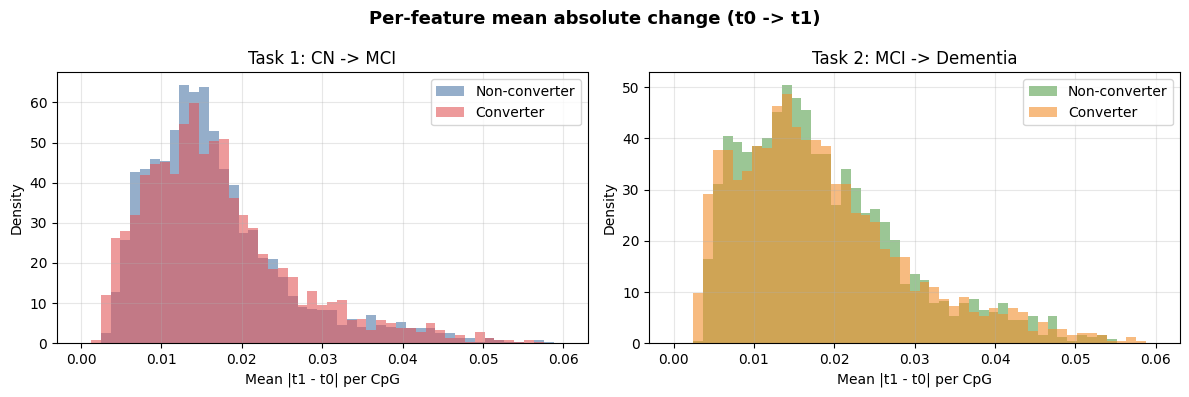

Saved longitudinal_delta.png


In [14]:
# Distribution of per-feature mean absolute delta per group
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, neg_key, pos_key) in zip(axes, tasks):
    delta_neg = np.abs(raw[neg_key][:, 1, :] - raw[neg_key][:, 0, :]).mean(axis=1)
    delta_pos = np.abs(raw[pos_key][:, 1, :] - raw[pos_key][:, 0, :]).mean(axis=1)
    bins = np.linspace(0, 0.06, 50)
    ax.hist(delta_neg, bins=bins, alpha=0.6, color=COLOURS[neg_key], label='Non-converter', density=True)
    ax.hist(delta_pos, bins=bins, alpha=0.6, color=COLOURS[pos_key], label='Converter', density=True)
    ax.set_title(title)
    ax.set_xlabel('Mean |t1 - t0| per CpG')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Per-feature mean absolute change (t0 -> t1)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT / 'longitudinal_delta.png', dpi=150)
plt.show()
print('Saved longitudinal_delta.png')

**Findings - Longitudinal structure**

- Within-individual t0-t1 Pearson correlation is **>= 0.998** (median) across all four groups - the two visits are nearly identical for every individual.
- Mean absolute methylation change per CpG is approximately **0.015-0.020**, a very small shift on the [0, 1] beta scale.
- The delta distribution (|t1 - t0|) is nearly identical between converters and non-converters - there is no visible separation, confirming that **methylation change does not discriminate between the two groups**.
- The relevant biological information is therefore encoded in the **baseline level** (t0), not in how methylation changes over the observation window.
- The near-zero within-individual variance also means a temporal transformer would learn almost nothing from the sequence dimension - its attention weights would be nearly uniform, providing no additional discriminative power over a single-timepoint representation.

## 5. CpG feature panel overlap between tasks

Task 1 and Task 2 use different pre-selected 2,000-feature panels (`cpg_ids_cn` vs `cpg_ids_mci`).  
Understanding the overlap matters for interpreting cross-task comparisons.

In [15]:
set_cn  = set(cpg_cn)
set_mci = set(cpg_mci)
shared  = set_cn & set_mci

print(f'Task 1 panel (cpg_ids_cn):   {len(set_cn):,} features')
print(f'Task 2 panel (cpg_ids_mci):  {len(set_mci):,} features')
print(f'Shared CpGs:                 {len(shared):,} ({len(shared)/2000:.1%} of each panel)')
print(f'Task-1 only:                 {len(set_cn - set_mci):,}')
print(f'Task-2 only:                 {len(set_mci - set_cn):,}')
print()
print('The two panels are largely independent; cross-task feature comparison is not meaningful.')

Task 1 panel (cpg_ids_cn):   2,000 features
Task 2 panel (cpg_ids_mci):  2,000 features
Shared CpGs:                 90 (4.5% of each panel)
Task-1 only:                 1,910
Task-2 only:                 1,910

The two panels are largely independent; cross-task feature comparison is not meaningful.


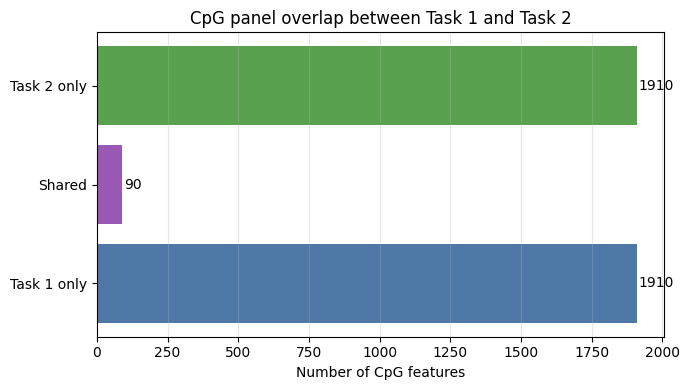

Saved cpg_overlap.png


In [16]:
# Venn-style bar chart
fig, ax = plt.subplots(figsize=(7, 4))
only_cn  = len(set_cn - set_mci)
only_mci = len(set_mci - set_cn)
shared_n = len(shared)
bars = ax.barh(['Task 1 only', 'Shared', 'Task 2 only'],
               [only_cn, shared_n, only_mci],
               color=['#4e79a7', '#9b59b6', '#59a14f'])
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center')
ax.set_xlabel('Number of CpG features')
ax.set_title('CpG panel overlap between Task 1 and Task 2')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / 'cpg_overlap.png', dpi=150)
plt.show()
print('Saved cpg_overlap.png')

**Findings - CpG panel overlap**

- Only **90 of 2,000 CpGs are shared** between the Task 1 and Task 2 panels (4.5% overlap). The panels are largely independent.
- Cross-task feature comparison (e.g., asking "which CpGs matter for both tasks?") is not valid on these panels - 95.5% of features are task-specific selections.
- The biological implication supports treating the tasks independently: the methylation regions that distinguish CN-to-MCI converters are mostly different from those that distinguish MCI-to-dementia converters. A joint model would require a common feature space that is not available here.

## 6. Per-feature variance: converters vs non-converters

The features were pre-selected by variance ratio between converters and non-converters.  
We visualise this selection effect to understand the feature panel's discriminative basis.

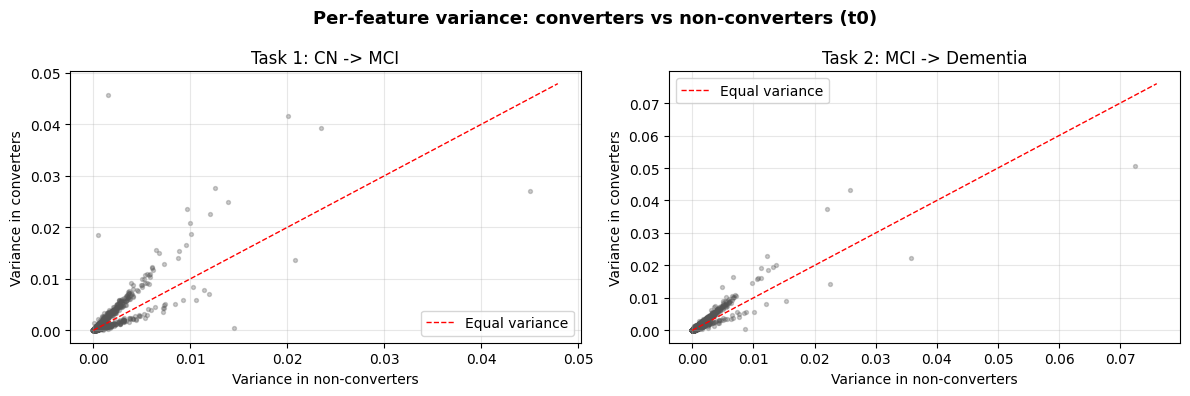

Saved feature_variance.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, neg_key, pos_key) in zip(axes, tasks):
    var_neg = raw[neg_key][:, 0, :].var(axis=1)   # variance across individuals at t0
    var_pos = raw[pos_key][:, 0, :].var(axis=1)
    ax.scatter(var_neg, var_pos, alpha=0.3, s=8, color='#555555')
    lim = max(var_neg.max(), var_pos.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1, label='Equal variance')
    ax.set_xlabel('Variance in non-converters')
    ax.set_ylabel('Variance in converters')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Per-feature variance: converters vs non-converters (t0)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT / 'feature_variance.png', dpi=150)
plt.show()
print('Saved feature_variance.png')

**Findings - Per-feature variance**

- Many CpGs sit **above the diagonal** in both tasks - their variance is higher in converters than in non-converters. This is the expected signature of variance-ratio feature selection.
- The selection effect is moderate rather than extreme: most points cluster near the diagonal, with a tail of high-variance-in-converters sites. The panel captures CpGs where converters are more variable, not necessarily where they have a different mean.
- **Critical limitation:** the variance ratio was computed on the **full dataset before any train/test split**. This means the feature panel itself encodes label information - a form of pre-selection leakage. All reported AUCs are optimistically biased relative to a pipeline where feature selection is repeated within each training fold. Since the full CpG matrix is not available, this cannot be corrected, but it must be kept in mind when interpreting absolute performance numbers.

## 7. Summary of findings and modelling implications

| Finding | Value | Modelling implication |
|---|---|---|
| Labels pre-defined by HDF5 group membership | - | No trajectory reconstruction needed; label decisions are inherited from the data provider |
| Exactly 2 timepoints per individual | T = 2 (fixed) | Use explicit temporal modes (t0, t1, concat, delta) rather than a sequence model |
| t0-t1 within-individual correlation | ~0.998 | Delta mode expected to carry little signal; baseline level is the primary carrier |
| Mean absolute delta per CpG | ~0.015-0.020 | Confirms delta is near-noise; longitudinal change does not discriminate groups |
| Task 1 positive rate | 22.6% (43/190) | Use class-weighted loss, PR-AUC as primary metric, stratified CV |
| Task 2 positive rate | 36.5% (110/301) | Less imbalanced but still warrants balanced loss weighting |
| CpG panel overlap | 4.5% (90/2000) | Tasks must be modelled independently; cross-task feature comparison is not valid |
| Feature pre-selection leakage | Global variance-ratio on full dataset | All AUCs optimistically biased; fold-wise reselection not possible without the full CpG matrix |

### Conclusions

The three most consequential findings from this EDA are:

**1. The temporal structure does not support a sequence model.** With exactly two timepoints and a within-individual correlation of 0.998, there is no meaningful sequence to learn from. A temporal transformer or RNN would be wasted capacity here. The right approach is a transparent ablation across explicit temporal representations, which also directly answers the clinical question of whether longitudinal change adds predictive value.

**2. The delta mode is expected to fail before modelling.** The near-zero mean absolute change per CpG means the delta input is dominated by measurement noise rather than biological signal. This prediction was confirmed empirically - delta mode produced near-chance performance across all models and both tasks.

**3. Feature pre-selection leakage sets a ceiling on the reliability of absolute AUC values.** The 2,000 features were selected using the full dataset's labels before any split. This inflates all reported AUCs to an unknown degree. The relative comparisons between models and temporal modes are still valid, but the absolute numbers should be treated with caution and not used as estimates of real-world performance on a new cohort.